# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [6]:
import os
import pandas as pd
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MACCSkeys
from rdkit.Chem import AllChem

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_geometric.data import Data


Load the data from Session 11

In [2]:
df = pd.read_csv("esol_modified.csv").dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [3]:
X=df["SMILES"].values
y=df["LogP"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

In [4]:
def smiles_to_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerator
[13:10:18] DEPRECATION WARNING: please use MorganGenerat

Mean Squared Error: 0.9195
R^2 Score: 0.7663


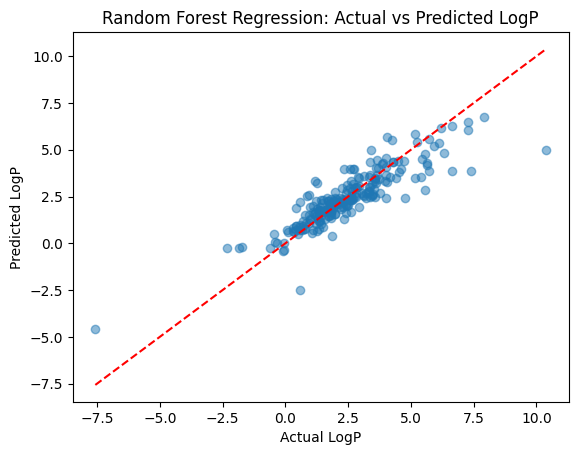

In [7]:

X_train_mols = np.array([smiles_to_fp(smiles) for smiles in X_train])
X_test_mols = np.array([smiles_to_fp(smiles) for smiles in X_test])

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train_mols, y_train)

y_pred = rf_model.predict(X_test_mols)

mse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Actual LogP")
plt.ylabel("Predicted LogP")
plt.title("Random Forest Regression: Actual vs Predicted LogP")
plt.show()

### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [6]:
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

In [7]:
def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [8]:
graphs = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df.iterrows()]

In [34]:
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=512):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )

        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)

        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch) # try: global_add_pool(x, batch)
        return self.lin(x).squeeze(-1)

In [35]:
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")


In [36]:
def create_splits(graphs, train_ratio=0.8, val_ratio=0.1, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:n_train + n_val]
    test_graphs  = graphs[n_train + n_val:]

    return train_graphs, val_graphs, test_graphs

train_graphs, val_graphs, test_graphs = create_splits(graphs)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=32)
test_loader  = DataLoader(test_graphs, batch_size=32)

In [37]:
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

loader = DataLoader(graphs, batch_size=100, shuffle=True)

In [40]:
#Load data and train GNN
gin = GINModel()

epochs = 100

print("\n=== Training GIN ===")
train(gin, train_loader, val_loader, epochs=epochs)
test(gin, test_loader)


=== Training GIN ===
Epoch 01 | Train Loss = 4.2889 | Val Loss = 4.4943
Epoch 02 | Train Loss = 3.1735 | Val Loss = 4.6868
Epoch 03 | Train Loss = 3.4155 | Val Loss = 4.2337
Epoch 04 | Train Loss = 2.8148 | Val Loss = 4.1329
Epoch 05 | Train Loss = 2.7158 | Val Loss = 3.7820
Epoch 06 | Train Loss = 2.7126 | Val Loss = 4.7301
Epoch 07 | Train Loss = 2.7209 | Val Loss = 3.4105
Epoch 08 | Train Loss = 2.5576 | Val Loss = 3.6297
Epoch 09 | Train Loss = 2.3711 | Val Loss = 3.2886
Epoch 10 | Train Loss = 2.4311 | Val Loss = 3.4034
Epoch 11 | Train Loss = 2.2468 | Val Loss = 2.8648
Epoch 12 | Train Loss = 2.1747 | Val Loss = 3.1115
Epoch 13 | Train Loss = 2.3402 | Val Loss = 2.5301
Epoch 14 | Train Loss = 2.1216 | Val Loss = 2.5932
Epoch 15 | Train Loss = 1.8699 | Val Loss = 2.7550
Epoch 16 | Train Loss = 1.7994 | Val Loss = 2.0327
Epoch 17 | Train Loss = 1.9901 | Val Loss = 2.4692
Epoch 18 | Train Loss = 2.0897 | Val Loss = 2.5742
Epoch 19 | Train Loss = 2.0314 | Val Loss = 1.7722
Epoch 20 

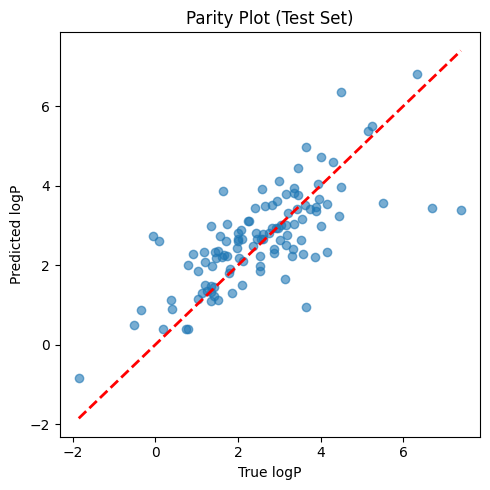

In [41]:
import matplotlib.pyplot as plt
def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

parity_plot(gin, test_loader)

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
RFR performed better given the limited data available; Better basis with Fingerprints

2) What did you try to improve model performance of your GNN? What did work, what did not work?
Inreasing the dimensions initially resulted improved performance, but increasing it further did not further improve the model in cost of the time necessary; changing the layers/depth only showed limited improvement 

3) Which challenges did you face in the process of building the models?
Main challenge was converting the SMILES into graphs, followed by hyperparamter testing/fitting of GNN

4) Which of your two models would you recommend to a chemist for predicting logP, and why?
If only a limited dataset is available RFR is easier, faster and more reliable; One advantage of GNN is that it can "visually" learn from 
uncommon/new structural motifs, where (standard) fingerprint system strugle

Overfitting = Model fits better than the trained data; Model is too complex than the data can provide for